-----------------------------
## Practice Hands-on case study: Linear Regression

-----------------------------

Welcome to the Hands-on case study on Linear Regression. In this case study, we aim to construct a linear model that explains the relationship a car's mileage (mpg) has with its other attributes

-----------------------------
## Dataset:
-----------------------------
There are 8 variables in the data:

- mpg: miles per gallon
- cyl: number of cylinders
- disp: engine displacement (cu. inches) or engine size
- hp: horsepower
- wt: vehicle weight (lbs.)
- acc: time taken to accelerate from O to 60 mph (sec.)
- yr: model year
- car name: car model name


- Also provided are the car labels (types)
- Missing data values are marked by series of question marks.

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Load and review data

In [ ]:
data = pd.read_csv("auto-mpg.csv")
data.shape

(398, 9)

In [ ]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
# Calculando a média da coluna mpg
average_mpg = data['mpg'].mean()
print(f"A milhagem média (MPG) dos carros neste dataset é: {average_mpg:.2f}")

A milhagem média (MPG) dos carros neste dataset é: 23.51


In [ ]:
#dropping/ignoring car_name
data = data.drop('car name', axis=1)
# Also replacing the categorical var with actual values
data['origin'] = data['origin'].replace({1: 'america', 2: 'europe', 3: 'asia'})
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,america
1,15.0,8,350.0,165,3693,11.5,70,america
2,18.0,8,318.0,150,3436,11.0,70,america
3,16.0,8,304.0,150,3433,12.0,70,america
4,17.0,8,302.0,140,3449,10.5,70,america


## Create Dummy Variables
Values like 'america' cannot be read into an equation. Using substitutes like 1 for america, 2 for europe and 3 for asia would end up implying that european cars fall exactly half way between american and asian cars! we dont want to impose such an baseless assumption!

So we create 3 simple true or false columns with titles equivalent to "Is this car America?", "Is this care European?" and "Is this car Asian?". These will be used as independent variables without imposing any kind of ordering between the three regions.




In [ ]:
data = pd.get_dummies(data, columns=['origin'])
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130,3504,12.0,70,True,False,False
1,15.0,8,350.0,165,3693,11.5,70,True,False,False
2,18.0,8,318.0,150,3436,11.0,70,True,False,False
3,16.0,8,304.0,150,3433,12.0,70,True,False,False
4,17.0,8,302.0,140,3449,10.5,70,True,False,False


## Dealing with Missing Values

In [ ]:
#A quick summary of the data columns
data.describe()

,mpg,cylinders,displacement,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000


In [ ]:
# hp is missing cause it does not seem to be reqcognized as a numerical column!
data.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,object
weight,int64
acceleration,float64
model year,int64
origin_america,bool
origin_asia,bool
origin_europe,bool


### Q.2 The method  used to check whether an entry of a column is a numerical value or is it missing?


In [ ]:
 # if the string is made of digits store True else False hint: use isdigit()
hpIsDigit = pd.DataFrame(data.horsepower.str.isdigit())


data[hpIsDigit['horsepower'] == False]   # from temp take only those rows where hp has false


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
32,25.0,4,98.0,?,2046,19.0,71,True,False,False
126,21.0,6,200.0,?,2875,17.0,74,True,False,False
330,40.9,4,85.0,?,1835,17.3,80,False,False,True
336,23.6,4,140.0,?,2905,14.3,80,True,False,False
354,34.5,4,100.0,?,2320,15.8,81,False,False,True
374,23.0,4,151.0,?,3035,20.5,82,True,False,False


In [ ]:
# Missing values have a'?''
# Replace missing values with NaN
data = data.replace('?', np.nan)
data[hpIsDigit['horsepower'] == False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
32,25.0,4,98.0,NaN,2046,19.0,71,True,False,False
126,21.0,6,200.0,NaN,2875,17.0,74,True,False,False
330,40.9,4,85.0,NaN,1835,17.3,80,False,False,True
336,23.6,4,140.0,NaN,2905,14.3,80,True,False,False
354,34.5,4,100.0,NaN,2320,15.8,81,False,False,True
374,23.0,4,151.0,NaN,3035,20.5,82,True,False,False


There are various ways to handle missing values. Drop the rows, replace missing values with median values etc. of the 398 rows 6 have NAN in the hp column. We could drop those 6 rows - which might not be a good idea under all situations


In [ ]:
#instead of dropping the rows, lets replace the missing values with median value.

data['horsepower'] = pd.to_numeric(data['horsepower'], errors='coerce')

# 2. Agora o data.median() vai funcionar porque horsepower é float!
# Vamos preencher os NaNs com a mediana
data = data.apply(lambda x: x.fillna(x.median()), axis=0)

# Verifique se o erro sumiu e se horsepower é float64
print(data.dtypes)
print(data.isnull().sum()) # Deve retornar tudo zero

data.median()

mpg               float64
cylinders           int64
displacement      float64
horsepower        float64
weight              int64
acceleration      float64
model year          int64
origin_america       bool
origin_asia          bool
origin_europe        bool
dtype: object
mpg               0
cylinders         0
displacement      0
horsepower        0
weight            0
acceleration      0
model year        0
origin_america    0
origin_asia       0
origin_europe     0
dtype: int64


,0
mpg,23.0
cylinders,4.0
displacement,148.5
horsepower,93.5
weight,2803.5
acceleration,15.5
model year,76.0
origin_america,1.0
origin_asia,0.0
origin_europe,0.0


### Filling the missing values with median value

In [ ]:
# replace the missing values with median value.
# Note, we do not need to specify the column names below
# every column's missing value is replaced with that column's median respectively  (axis =0 means columnwise)

medianFiller = lambda x: x.fillna(x.median())
data = data.apply(medianFiller,axis=0)



data['horsepower'] = data['horsepower'].astype('float64')  # converting the hp column from object / string type to float


## BiVariate Plots

A bivariate analysis among the different variables can be done using scatter matrix plot. Seaborn libs create a dashboard reflecting useful information about the dimensions. The result can be stored as a .png file.

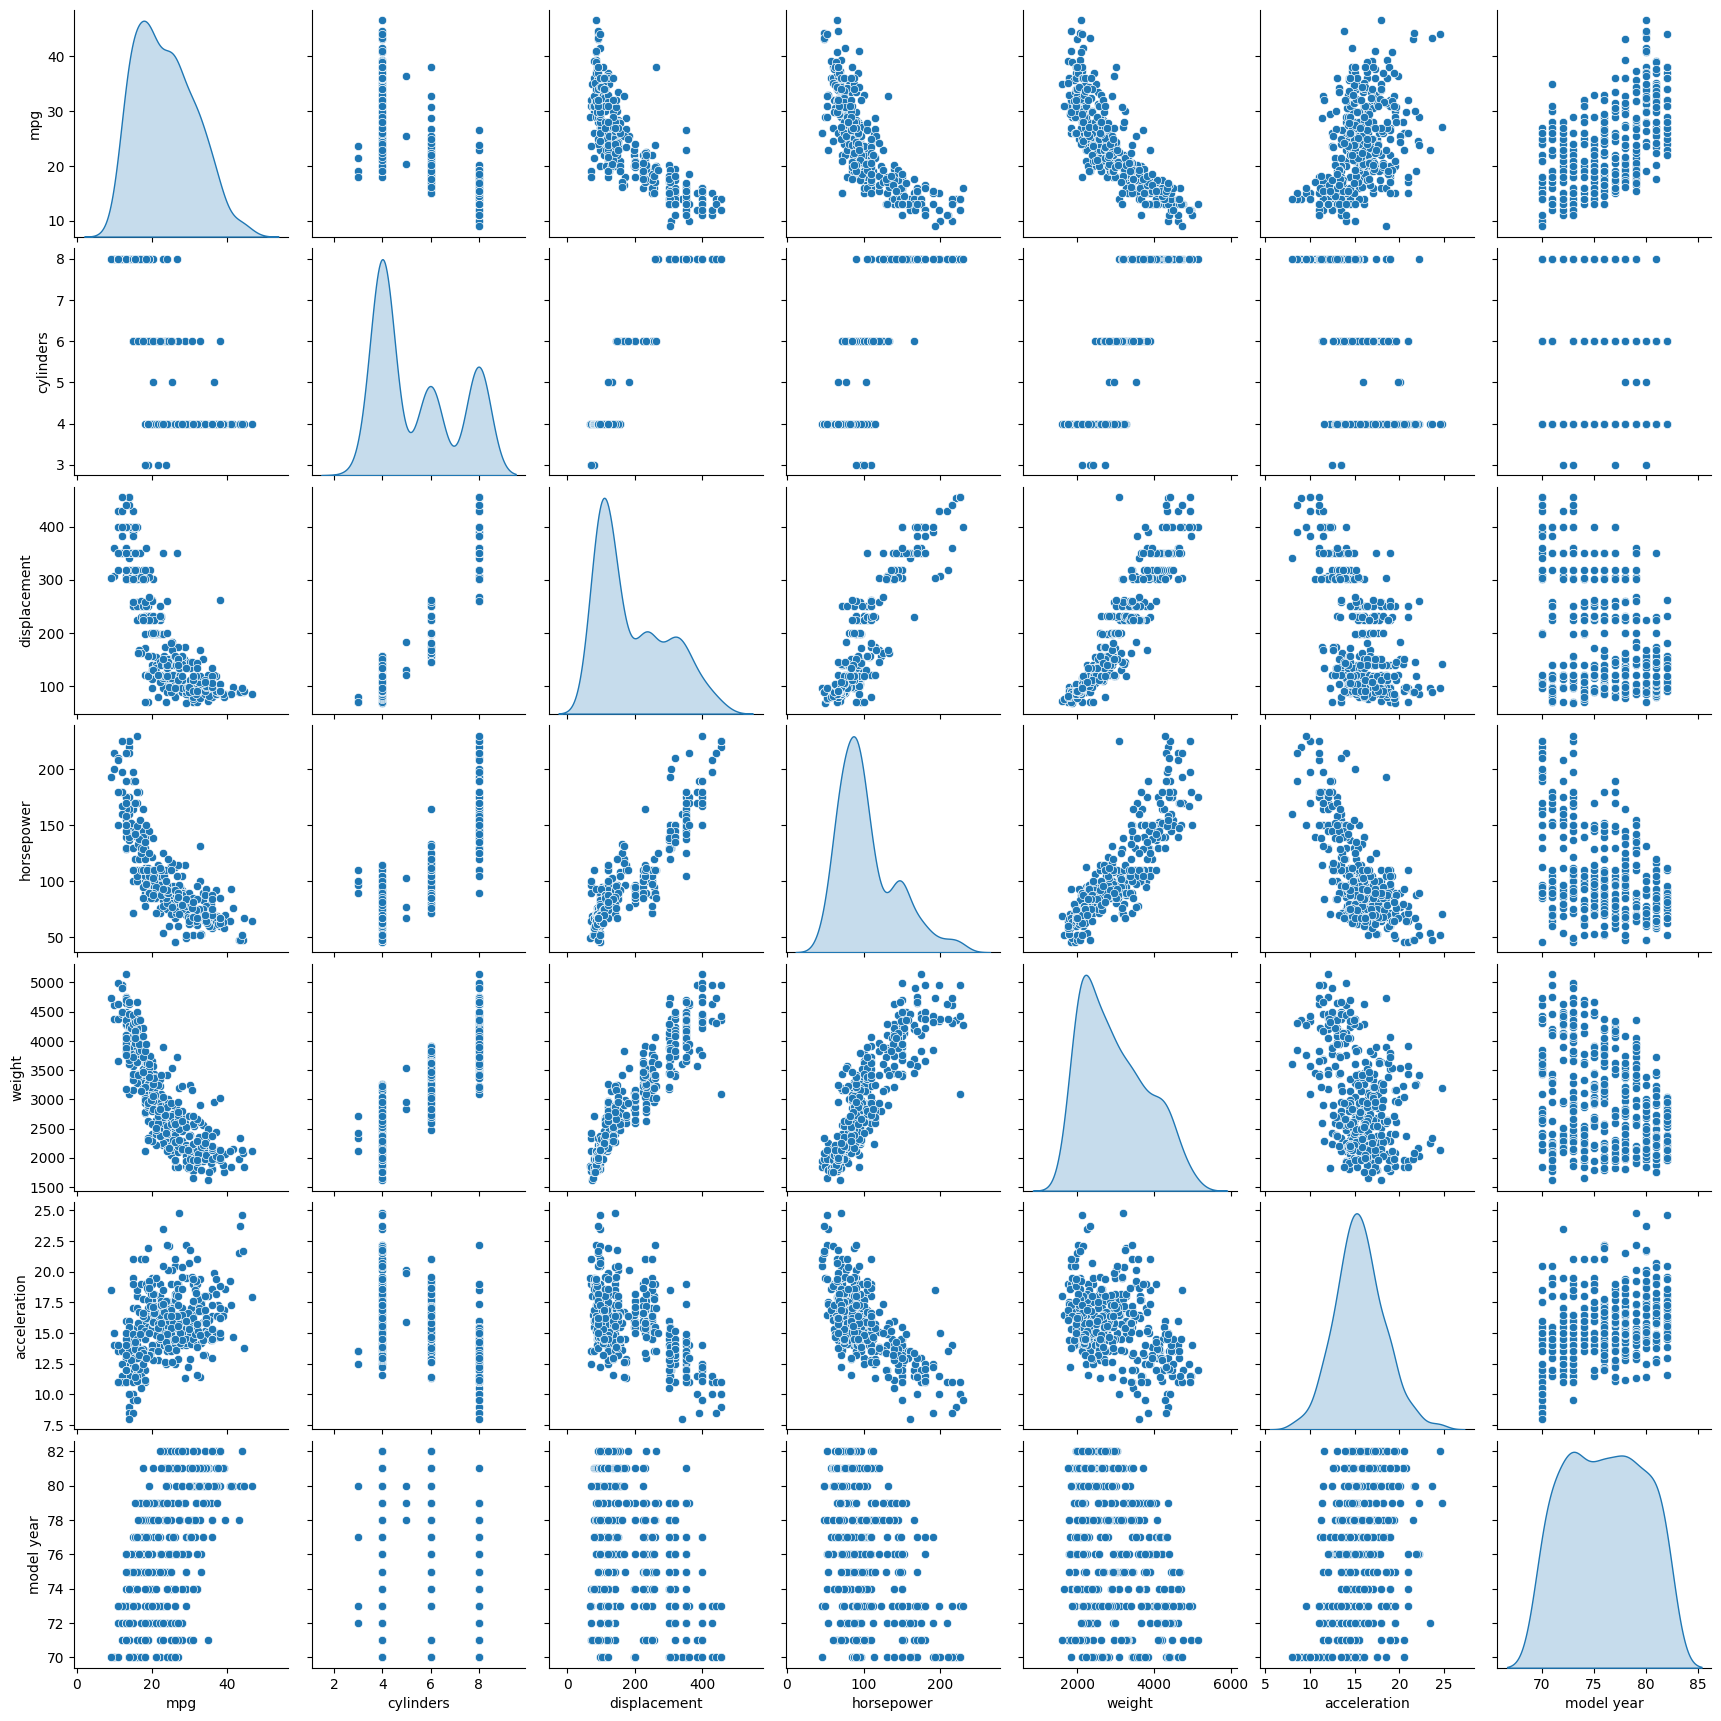

In [ ]:
data_attr = data.iloc[:, 0:7]
sns.pairplot(data_attr, diag_kind='kde')   # to plot density curve instead of histogram on the diag

Observation between 'mpg' and other attributes indicate the relationship is not really linear. However, the plots also indicate that linearity would still capture quite a bit of useful information/pattern. Several assumptions of classical linear regression seem to be violated, including the assumption of no Heteroscedasticity


## Split Data

In [ ]:
# lets build our linear model
# independant variables
X = data.drop(columns=['mpg', 'origin_europe', 'car name'], errors='ignore')
# the dependent variable
y = data['mpg']

In [ ]:

data['origin_america'] = data['origin_america'].astype(int)
data['origin_asia'] = data['origin_asia'].astype(int)
data['origin_europe'] = data['origin_europe'].astype(int)


In [ ]:
data.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model year,int64
origin_america,int64
origin_asia,int64
origin_europe,int64


In [ ]:
# Sklearn package's model_selection have a function train_test_split() is used for data splitting into test(out of sample) and train dataset
from sklearn.model_selection import train_test_split


# Split X and y into training and test set(out of sample data) in 70:30 ratio

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

### Q.3 & 4 Create linear regression model using statsmodels OLS and interpretate coefficient

In [ ]:
# 1. Garantir que as colunas de origem sejam números (0 e 1) em vez de True/False
data['origin_america'] = data['origin_america'].astype(int)
data['origin_asia'] = data['origin_asia'].astype(int)
data['origin_europe'] = data['origin_europe'].astype(int)

# 2. Recriar X removendo EXPLICITAMENTE a coluna 'car name'
# O erro acontece porque o Statsmodels tenta ler essa coluna de texto
X = data.drop(columns=['mpg', 'origin_europe', 'car name'], errors='ignore')
y = data['mpg']

# 3. Refazer o split para garantir que X_train não tenha lixo
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

# 4. Agora sim, o código do Statsmodels
import statsmodels.api as sm

X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)

# O erro deve sumir aqui
model1 = sm.OLS(y_train, X_train_ols).fit()

# Exibir o resumo
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     147.3
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.20e-93
Time:                        21:55:15   Log-Likelihood:                -734.21
No. Observations:                 278   AIC:                             1486.
Df Residuals:                     269   BIC:                             1519.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -18.2835      5.549     -3.

In [ ]:


# 2. Recriar X removendo EXPLICITAMENTE a coluna 'car name'
# O erro acontece porque o Statsmodels tenta ler essa coluna de texto
X = data.drop(columns=['mpg', 'origin_europe', 'car name','cylinders','horsepower','acceleration','origin_asia'], errors='ignore')
y = data['mpg']

# 3. Refazer o split para garantir que X_train não tenha lixo
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

# 4. Agora sim, o código do Statsmodels
import statsmodels.api as sm

X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)

# O erro deve sumir aqui
model1 = sm.OLS(y_train, X_train_ols).fit()

# Exibir o resumo
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     290.2
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           5.31e-97
Time:                        22:02:19   Log-Likelihood:                -737.54
No. Observations:                 278   AIC:                             1485.
Df Residuals:                     273   BIC:                             1503.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -19.6324      4.826     -4.

- Not all the variables are statistically significant to predict the outcome variable. To check which are statistically significant or have predictive power to predict the target variable, we need to check the `p-value` against all the independent variables.
- **Interpreting the Regression Results:**

1. **Adjusted. R-squared**: It reflects the fit of the model.
    - R-squared values range from 0 to 1, where a higher value generally indicates a better fit, assuming certain conditions are met.
    
2. **coeff**: It represents the change in the output Y due to a change of one unit in the variable (everything else held constant).
3. **std err**: It reflects the level of accuracy of the coefficients.
    - The lower it is, the more accurate the coefficients are.
4. **P >|t|**: It is p-value.
   
   * Pr(>|t|) : For each independent feature there is a null hypothesis and alternate hypothesis

    Ho : Independent feature is not significant
   
    Ha : Independent feature is significant
    
   * A p-value of less than 0.05 is considered to be statistically significant.

   
5. **Confidence Interval**: It represents the range in which our coefficients are likely to fall (with a likelihood of 95%).

* To be able to make statistical inferences from our model, **we will have to test the significance of the regression coefficients and linear regression assumptions.**

### Checking the performance of the model on the train and test data set

In [ ]:
# RMSE
def rmse(predictions, targets):
    return np.sqrt(((targets - predictions) ** 2).mean())


# MAPE
def mape(predictions, targets):
    return np.mean(np.abs((targets - predictions)) / targets) * 100


# MAE
def mae(predictions, targets):
    return np.mean(np.abs((targets - predictions)))


# Model Performance on test and train data
def model_pref(olsmodel, x_train, x_test, y_train,y_test):

    # Insample Prediction
    y_pred_train = olsmodel.predict(x_train)
    y_observed_train = y_train

    # Prediction on test data
    y_pred_test = olsmodel.predict(x_test)
    y_observed_test = y_test

    print(
        pd.DataFrame(
            {
                "Data": ["Train", "Test"],
                "RMSE": [
                    rmse(y_pred_train, y_observed_train),
                    rmse(y_pred_test, y_observed_test),
                ],
                "MAE": [
                    mae(y_pred_train, y_observed_train),
                    mae(y_pred_test, y_observed_test),
                ],
                "MAPE": [
                    mape(y_pred_train, y_observed_train),
                    mape(y_pred_test, y_observed_test),
                ],
            }
        )
    )


# Checking model performance
model_pref(model1, X_train_ols, X_test_ols,y_train,y_test)

    Data      RMSE       MAE       MAPE
0  Train  3.435286  2.625086  12.212578
1   Test  2.996723  2.316491  10.945334


**Observations:**

* RMSE, MAE, and MAPE of train and test data are not very different, indicating that the **model is not overfitting and has generalized well.**

### Question 5: Performing cross validation and comparing its average performance to OLS performance

In [ ]:
# import the required function
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# build the regression model using Sklearn Linear regression
linearregression = LinearRegression()

#remove ________ and cross_val_score and complete the code
cv_Score11 = cross_val_score(linearregression, X, y, cv=10) #cv=10 represents data is divided into 10 folds.
cv_Score12 = cross_val_score(linearregression, X, y, cv=10, scoring = 'neg_mean_squared_error')


print("RSquared: %0.3f (+/- %0.3f)" % (cv_Score11.mean(), cv_Score11.std() * 2))
print("Mean Squared Error: %0.3f (+/- %0.3f)" % (-1*cv_Score12.mean(), cv_Score12.std() * 2))


RSquared: 0.648 (+/- 0.457)
Mean Squared Error: 12.382 (+/- 15.168)


### Get model Coefficients in a pandas dataframe with column 'Feature' having all the features and column 'Coefs' with all the corresponding Coefs. Write the regression equation.

In [ ]:
coef = model1.params
coef

,0
const,-19.632374
displacement,0.014136
weight,-0.007433
model year,0.842272
origin_america,-2.227924


In [ ]:
# Let us write the equation of the fit
Equation = "log (car_mileage) ="
print(Equation, end='\t')
for i in range(len(coef)):
    print('(', coef[i], ') * ', coef.index[i], '+', end = ' ')

log (car_mileage) =	( -19.63237409595428 ) *  const + ( 0.014136124996781952 ) *  displacement + ( -0.007433311868022525 ) *  weight + ( 0.8422721579931748 ) *  model year + ( -2.227924337829761 ) *  origin_america + 

/tmp/ipython-input-1038366294.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('(', coef[i], ') * ', coef.index[i], '+', end = ' ')


### Building Decision Tree

In [ ]:
#importing Decision tree regressor using sklearn

from sklearn.tree import DecisionTreeRegressor

In [ ]:
# splitting the data in 70:30 ratio of train to test data
# separate the dependent and indepedent variable
Y1 = data['mpg']
X1 = data.drop(columns = {'mpg','origin_europe'})
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, Y1, test_size=0.30 , random_state=1)

### Question 6: Building Decision tree and Checking its performance

In [ ]:

dt = DecisionTreeRegressor(random_state=1)


dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

Checking model perform on the train and test dataset

In [ ]:
model_pref(dt, X_train, X_test, y_train, y_test)

    Data      RMSE       MAE       MAPE
0  Train  0.000000  0.000000   0.000000
1   Test  3.706829  2.385833  10.231833


**Observations:**

- **The model seem to overfit the data** as rmse, mae and mape value of train data is 0, but that value for test data is much higher.

In [ ]:
from sklearn.tree import plot_tree

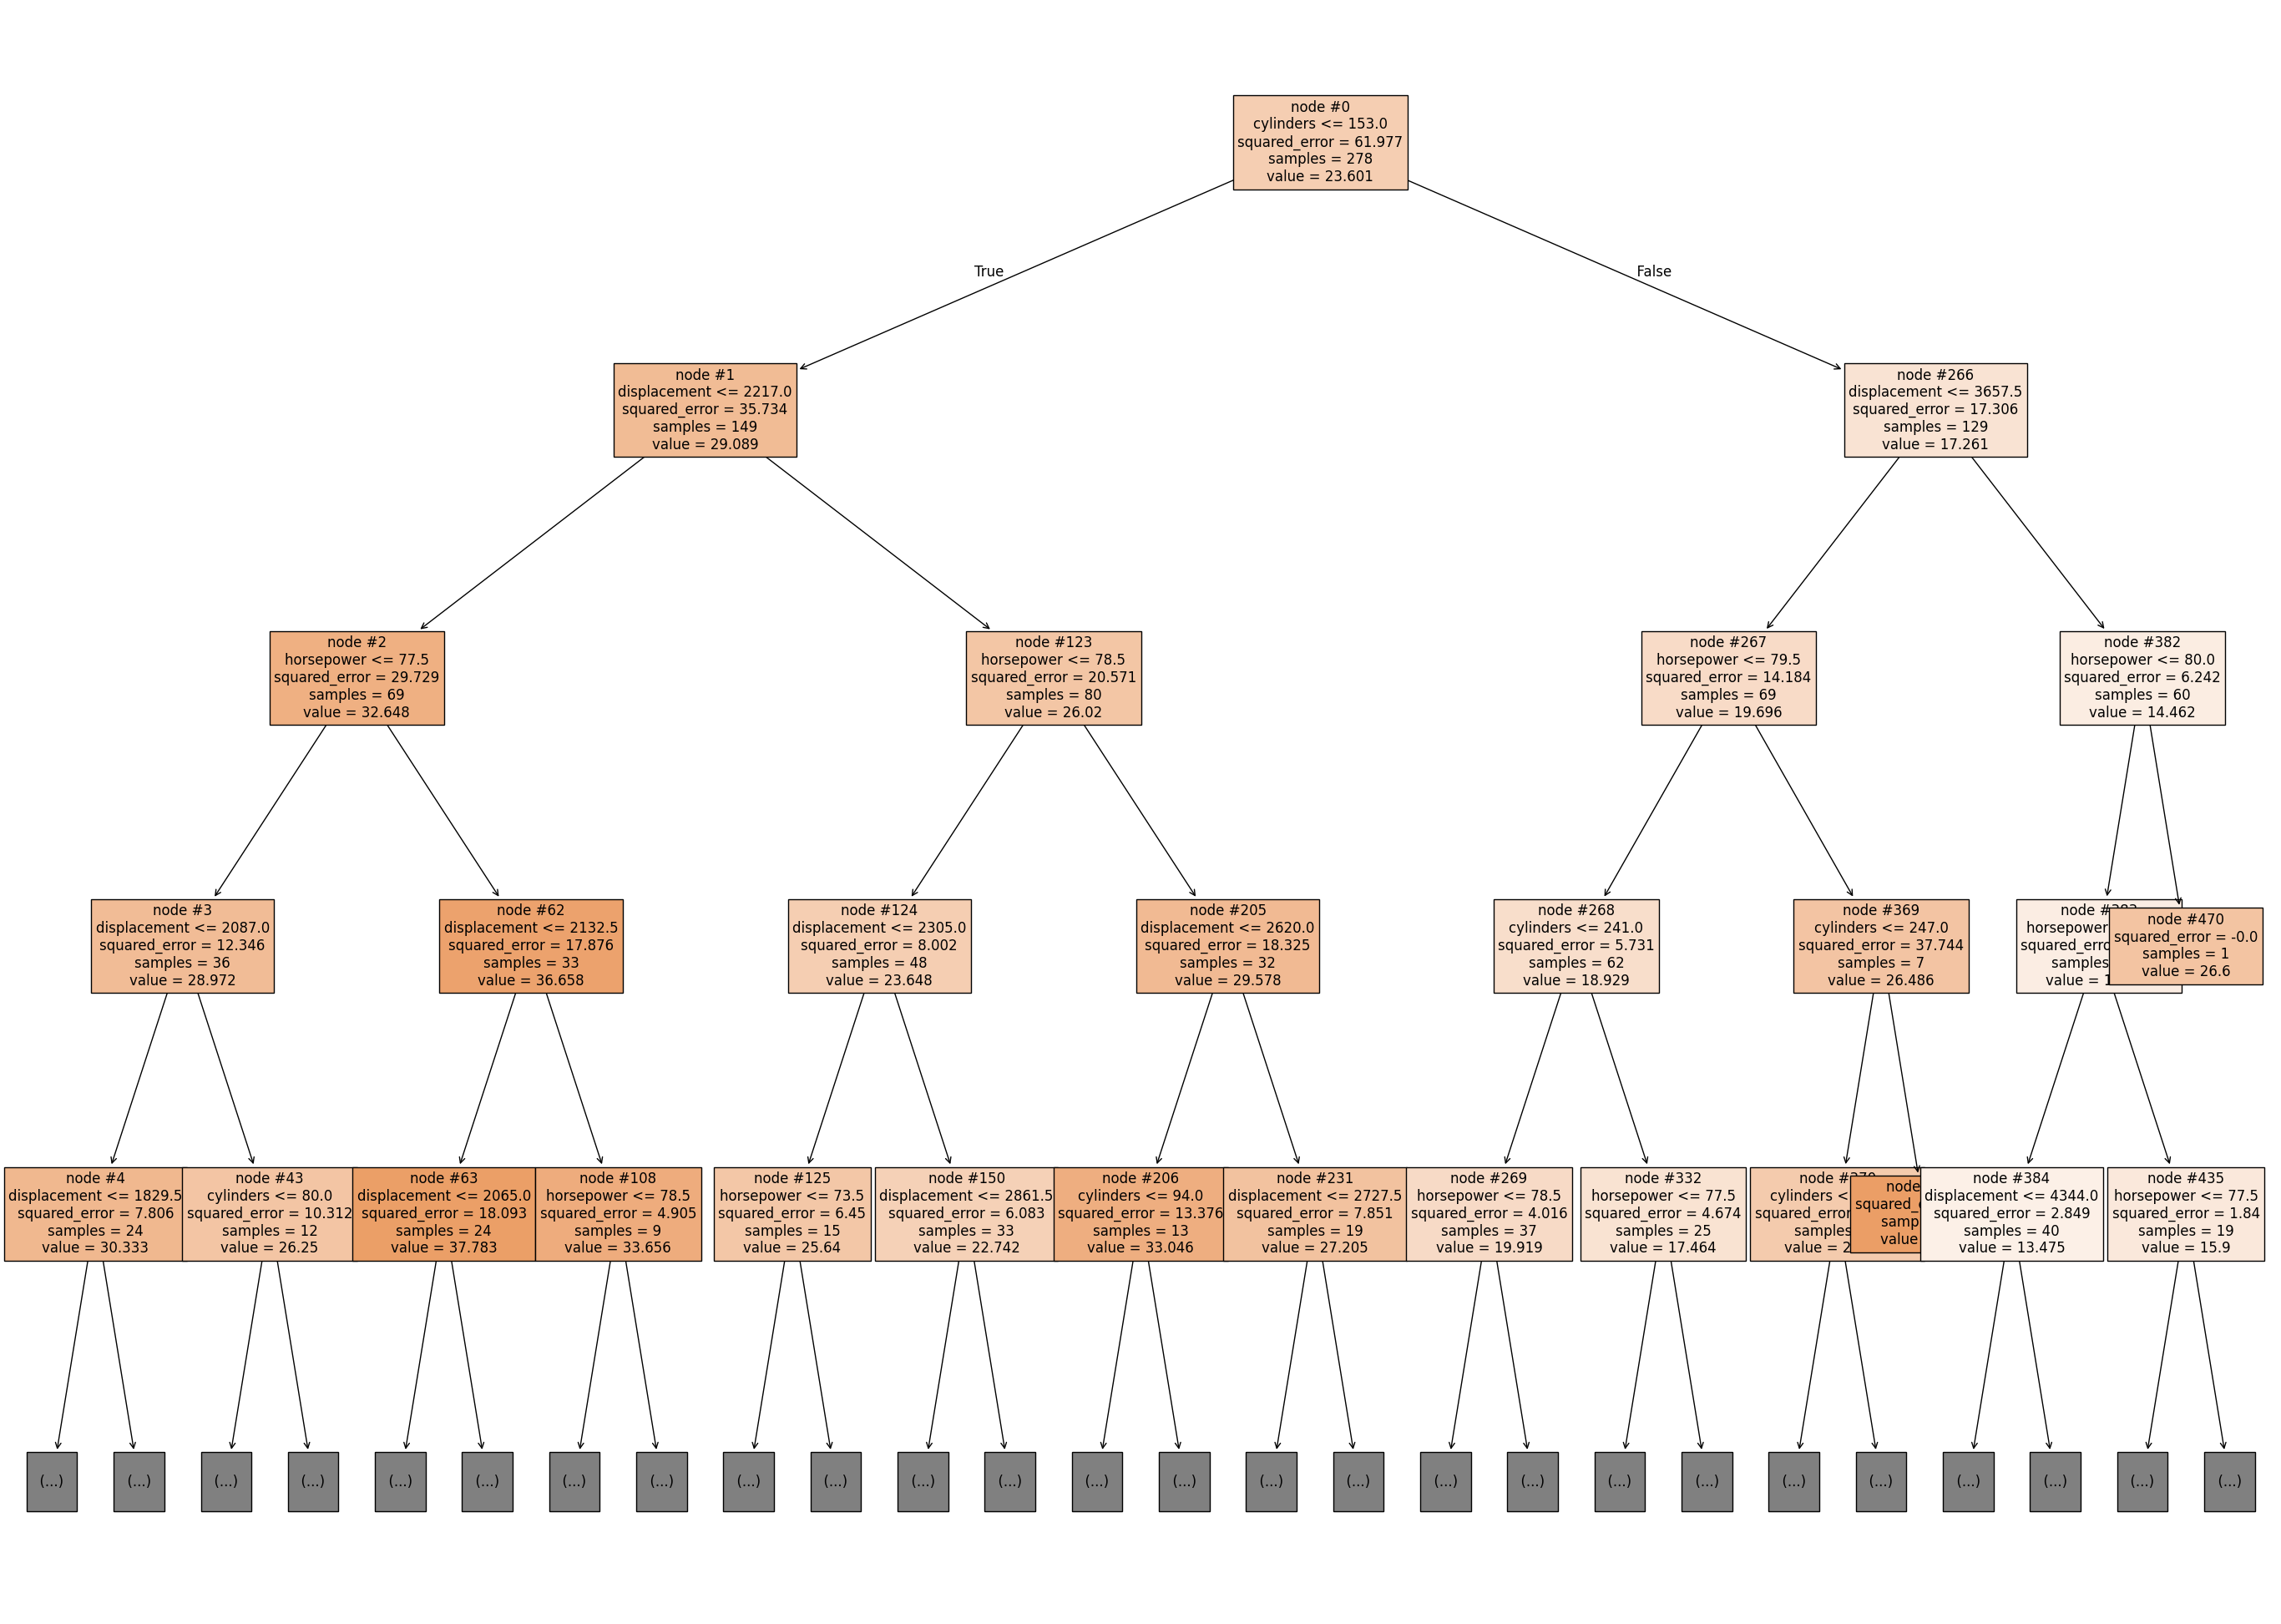

In [ ]:
features = list(X1.columns)

plt.figure(figsize=(35,25))
plot_tree(dt, max_depth=4, feature_names=features,filled=True,fontsize=12,node_ids=True,class_names=True)
plt.show()

#### Let's plot the feature importance for each variable in the dataset and analyze the variables

### Checking Feature importance

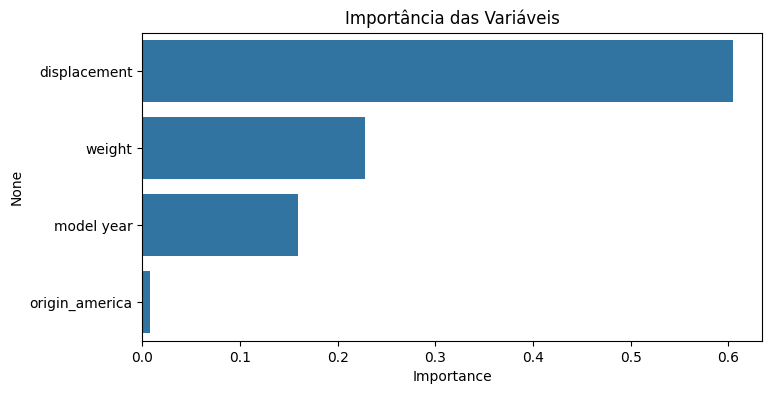

In [ ]:
# 1. Pegar as importâncias do modelo atual
importances = dt.feature_importances_

# 2. Usar as colunas do X_train (ou do X que você usou no fit do dt)
# Se o seu dt foi treinado com o X reduzido, use X_train.columns
columns = X_train.columns

# 3. Criar o DataFrame (Agora os tamanhos vão bater: 4 e 4)
importance_df = pd.DataFrame(importances, index=columns, columns=['Importance']).sort_values(by='Importance', ascending=False)

# 4. Plotar
plt.figure(figsize=(8,4))
sns.barplot(x=importance_df.Importance, y=importance_df.index)
plt.title('Importância das Variáveis')
plt.show()

### Building Random Forest

In [ ]:
#importing random forest regressor usinf sklearn

from sklearn.ensemble import RandomForestRegressor

#### Parameters for regression
**n_estimators**: The number of trees in the forest.

**min_samples_split**: The minimum number of samples required to split an internal node:

**max_depth**
The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

**max_features{“auto”, “sqrt”, “log2”, 'None'}**: The number of features to consider when looking for the best split.

- If “auto”, then max_features=sqrt(n_features).

- If “sqrt”, then max_features=sqrt(n_features) (same as “auto”).

- If “log2”, then max_features=log2(n_features).

- If None, then max_features=n_features.

In [ ]:
#defining the Random forest regressor
#remove ________ and define random forest tree and complete the code
rf=RandomForestRegressor(n_estimators=100, random_state=1)

#Hyperparameters, we have randomly choosen them for now but we can tune these hyperparameters and get the best model.

#fitting the model
#remove ________ and fit random forest tree and complete the code
rf.fit(X_train1, y_train1)

RandomForestRegressor(random_state=1)

### Q.7 Check performance of Random Forest

In [ ]:
# checking model performance on test dataset
rf.score(X_test1, y_test1)

0.8665991000897517

In [ ]:
model_pref(rf, X_train1, X_test1,y_train1,y_test1)

    Data      RMSE       MAE      MAPE
0  Train  1.031129  0.714655  3.025346
1   Test  2.792766  1.957267  8.527698


### Question 8 & 9: Checking the feature importance of each variable in Random Forest and comparing to Decision Tree

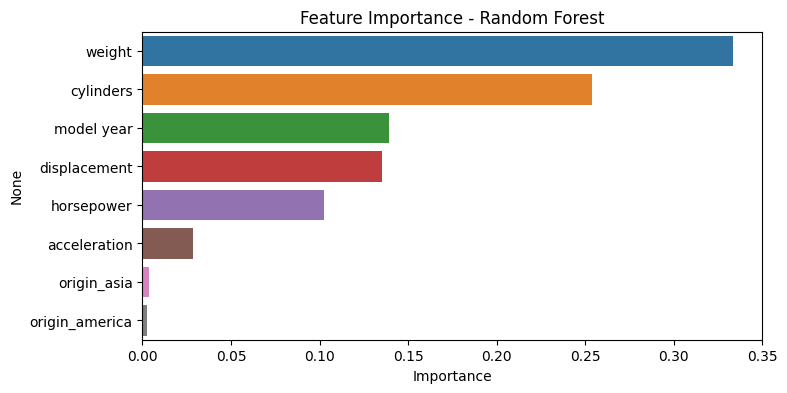

In [ ]:
# 1. Extraindo as importâncias
importances = rf.feature_importances_

# 2. Criando o DataFrame
columns = X1.columns
importance_df = pd.DataFrame(importances, index=columns, columns=['Importance']).sort_values(by='Importance', ascending=False)

# 3. Plotando o gráfico (Correção: especificando x= e y=)
plt.figure(figsize=(8,4))
sns.barplot(x=importance_df.Importance, y=importance_df.index, hue=importance_df.index, legend=False)
plt.title('Feature Importance - Random Forest')
plt.show()



### Question 10: Comparing results of three model

In [ ]:
print("Linear Regression")
model_pref(model1, X_train_ols, X_test_ols,y_train,y_test)
print("Decision tree")
model_pref(dt, X_train1, X_test1,y_train1,y_test1)
print("Random Forest")
model_pref(rf, X_train1, X_test1,y_train1,y_test1)

Linear Regression
    Data      RMSE       MAE       MAPE
0  Train  3.435286  2.625086  12.212578
1   Test  2.996723  2.316491  10.945334
Decision tree


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- acceleration
- cylinders
- horsepower
- origin_asia
